# Stroke Prediction – Exploratory Data Analysis

**Dataset**: [Stroke Prediction Dataset](https://www.kaggle.com/datasets/fedesoriano/stroke-prediction-dataset)  
**Goal**: Understand the data distribution, class imbalance, and feature relationships before modelling.

---

In [1]:
import sys
from pathlib import Path

# Allow imports from src/
sys.path.insert(0, str(Path('..') / 'src'))

import warnings
warnings.filterwarnings('ignore')

import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import numpy as np
import pandas as pd
import seaborn as sns

sns.set_theme(style='whitegrid', palette='muted', font_scale=1.15)
plt.rcParams['figure.dpi'] = 120

from data_loader import load_raw, DATA_PATH

df = load_raw(DATA_PATH)
print(df.shape)
df.head()

(5610, 12)


,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1


## 1. Dataset Overview

In [2]:
print('── Shape:', df.shape)
print('── Dtypes\n', df.dtypes)
print('── Missing values\n', df.isnull().sum())
df.describe()

── Shape: (5610, 12)
── Dtypes
 id                     int64
gender                object
age                  float64
hypertension           int64
heart_disease          int64
ever_married          object
work_type             object
Residence_type        object
avg_glucose_level    float64
bmi                  float64
smoking_status        object
stroke                 int64
dtype: object
── Missing values
 id                     0
gender                 0
age                    0
hypertension           0
heart_disease          0
ever_married           0
work_type              0
Residence_type         0
avg_glucose_level      0
bmi                  201
smoking_status         0
stroke                 0
dtype: int64


,id,age,hypertension,heart_disease,avg_glucose_level,bmi,stroke
count,5610.000000,5610.000000,5610.000000,5610.000000,5610.000000,5409.000000,5610.000000
mean,39786.338324,45.430624,0.111765,0.066132,108.587071,29.013126,0.133512
std,22739.875815,23.000300,0.315105,0.248535,46.932275,7.721962,0.340157
min,67.000000,0.080000,0.000000,0.000000,55.000000,10.300000,0.000000
25%,19802.000000,27.000000,0.000000,0.000000,77.542500,23.800000,0.000000
50%,40454.000000,48.000000,0.000000,0.000000,93.235000,28.200000,0.000000
75%,59943.750000,63.000000,0.000000,0.000000,119.895000,33.200000,0.000000
max,73440.000000,95.000000,1.000000,1.000000,280.000000,97.600000,1.000000


**Key observations**
- `bmi` has **201 NaN** values (stored as `'N/A'` strings in raw CSV).
- `id` is an arbitrary identifier → will be dropped.
- Target `stroke` is heavily imbalanced (~4.9 % positive).

## 2. Target Distribution (Class Imbalance)

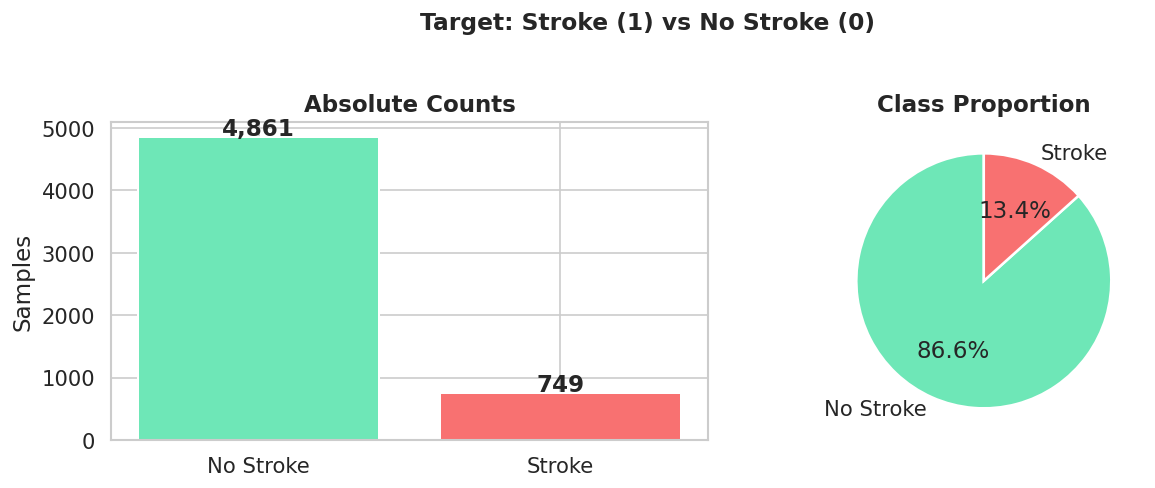

Positive rate: 13.35%  →  severe class imbalance


In [3]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

counts = df['stroke'].value_counts()
labels = ['No Stroke', 'Stroke']
colors = ['#6EE7B7', '#F87171']

# Bar chart
axes[0].bar(labels, counts.values, color=colors, edgecolor='white', linewidth=1.2)
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 30, f'{v:,}', ha='center', fontweight='bold')
axes[0].set_title('Absolute Counts', fontweight='bold')
axes[0].set_ylabel('Samples')

# Pie chart
axes[1].pie(
    counts.values, labels=labels, colors=colors, autopct='%1.1f%%',
    startangle=90, wedgeprops=dict(edgecolor='white', linewidth=1.5)
)
axes[1].set_title('Class Proportion', fontweight='bold')

fig.suptitle('Target: Stroke (1) vs No Stroke (0)', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()
print(f'Positive rate: {df["stroke"].mean()*100:.2f}%  →  severe class imbalance')

## 3. Age Distribution by Stroke

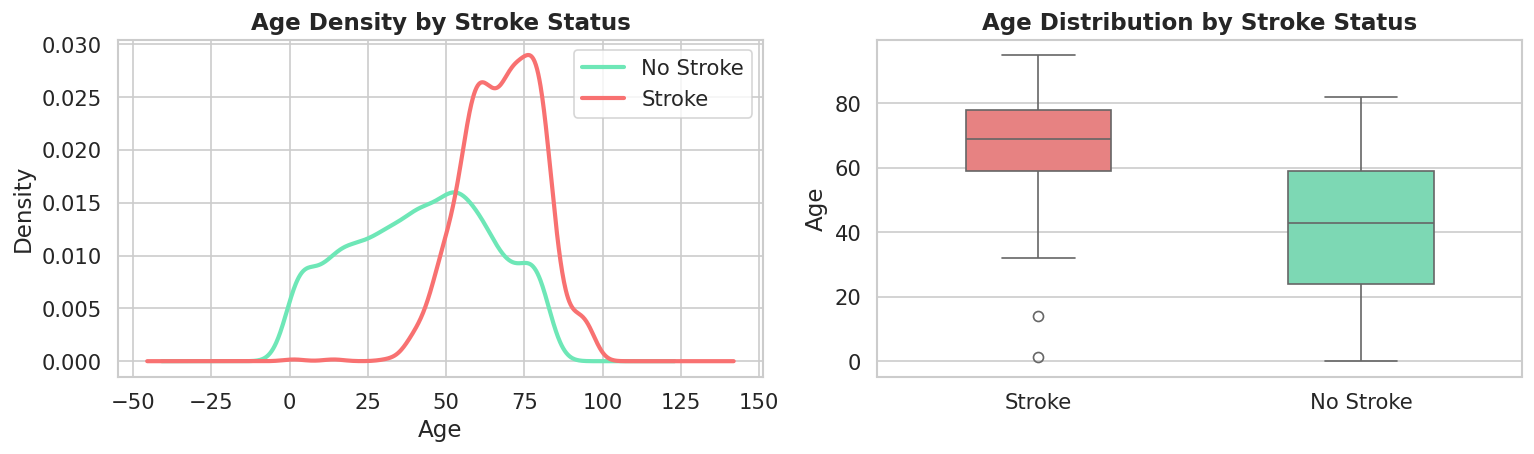

Median age – No Stroke: 43.0
Median age – Stroke:    69.0


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# KDE overlay
for label, grp in df.groupby('stroke'):
    name = 'Stroke' if label == 1 else 'No Stroke'
    color = '#F87171' if label == 1 else '#6EE7B7'
    grp['age'].plot.kde(ax=axes[0], label=name, color=color, lw=2.5)
axes[0].set_title('Age Density by Stroke Status', fontweight='bold')
axes[0].set_xlabel('Age')
axes[0].legend()

# Box plot
df['stroke_label'] = df['stroke'].map({0: 'No Stroke', 1: 'Stroke'})
sns.boxplot(
    data=df, x='stroke_label', y='age', palette={'No Stroke': '#6EE7B7', 'Stroke': '#F87171'},
    ax=axes[1], width=0.45
)
axes[1].set_title('Age Distribution by Stroke Status', fontweight='bold')
axes[1].set_xlabel('')
axes[1].set_ylabel('Age')

plt.tight_layout()
plt.show()
print('Median age – No Stroke:', df.loc[df.stroke==0,'age'].median())
print('Median age – Stroke:   ', df.loc[df.stroke==1,'age'].median())

## 4. Categorical Features – Stroke Rate by Category

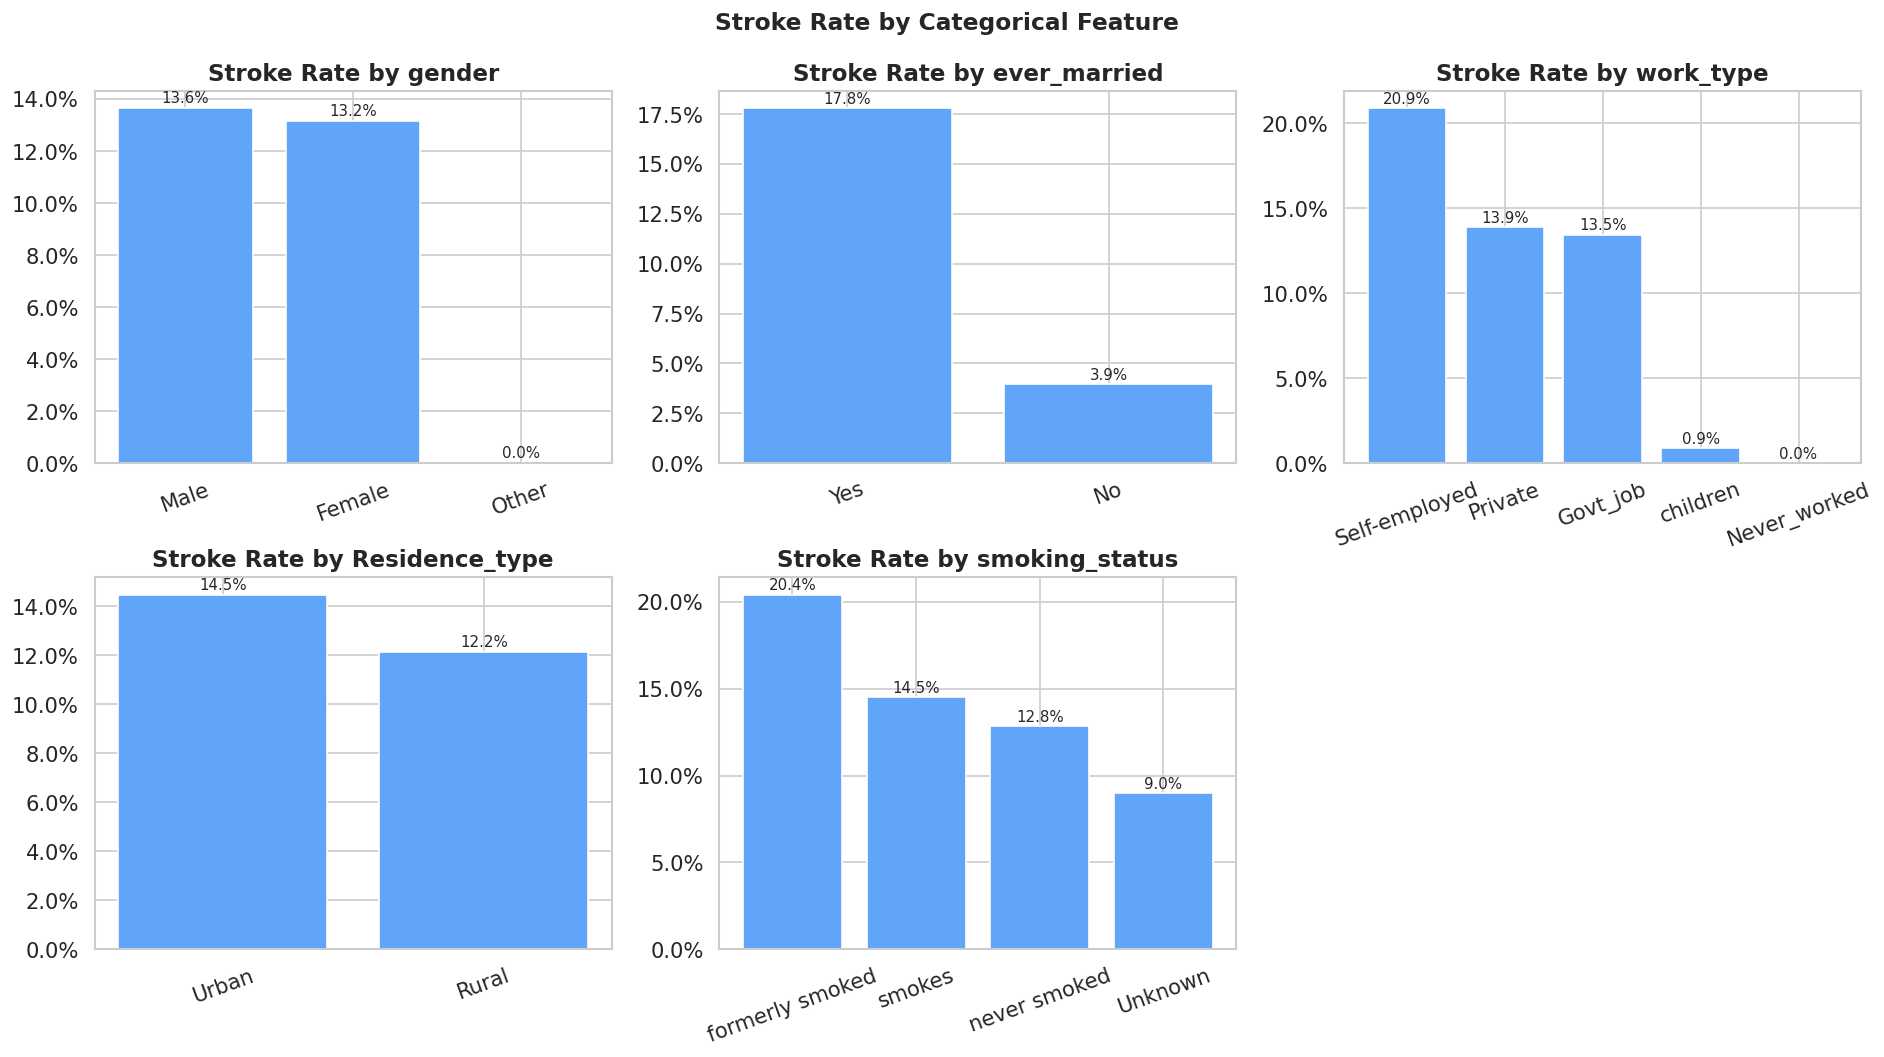

In [5]:
cat_cols = ['gender', 'ever_married', 'work_type', 'Residence_type', 'smoking_status']

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

for ax, col in zip(axes, cat_cols):
    stroke_rate = df.groupby(col)['stroke'].mean().sort_values(ascending=False)
    bars = ax.bar(stroke_rate.index, stroke_rate.values * 100,
                  color='#60A5FA', edgecolor='white', linewidth=1)
    ax.yaxis.set_major_formatter(mtick.PercentFormatter())
    ax.set_title(f'Stroke Rate by {col}', fontweight='bold')
    ax.set_xlabel('')
    ax.tick_params(axis='x', rotation=20)
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, h + 0.1, f'{h:.1f}%',
                ha='center', va='bottom', fontsize=9)

axes[-1].set_visible(False)
fig.suptitle('Stroke Rate by Categorical Feature', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 5. Continuous Features – Distributions & Stroke Overlap

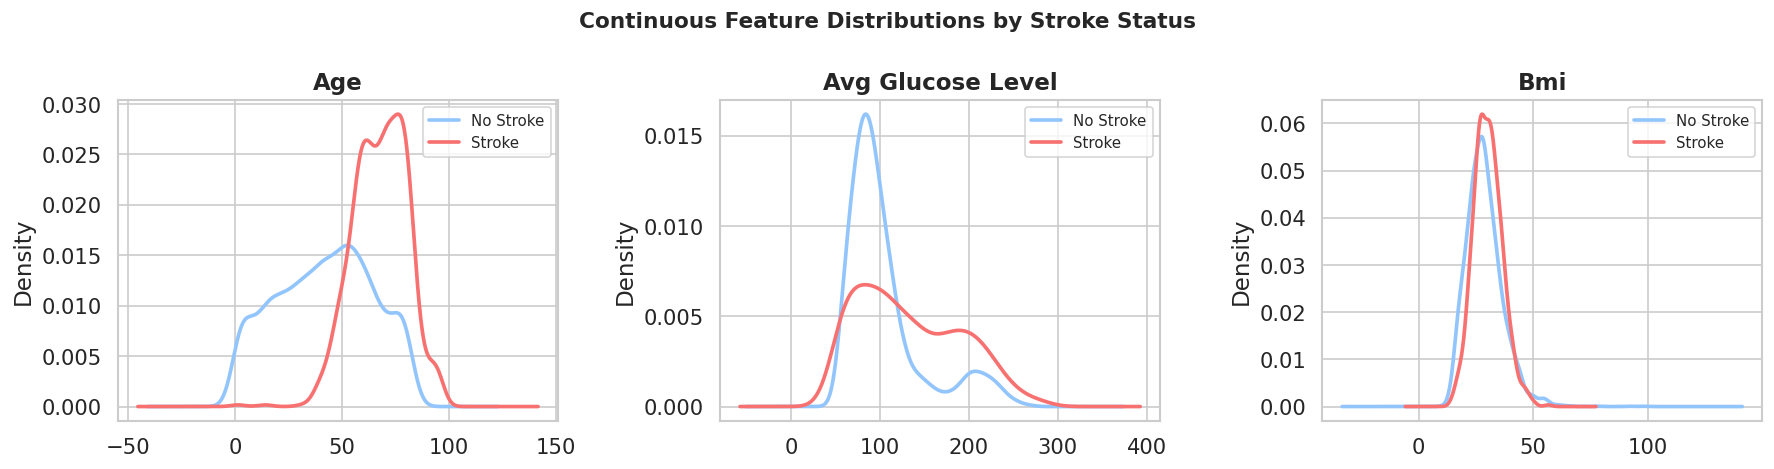

In [6]:
cont_cols = ['age', 'avg_glucose_level', 'bmi']

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, col in zip(axes, cont_cols):
    for label, grp in df.groupby('stroke'):
        name   = 'Stroke' if label == 1 else 'No Stroke'
        color  = '#F87171' if label == 1 else '#93C5FD'
        grp[col].dropna().plot.kde(ax=ax, label=name, color=color, lw=2.2)
    ax.set_title(col.replace('_', ' ').title(), fontweight='bold')
    ax.set_xlabel('')
    ax.legend(fontsize=9)

fig.suptitle('Continuous Feature Distributions by Stroke Status', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 6. Risk Factor Heatmap – Hypertension & Heart Disease

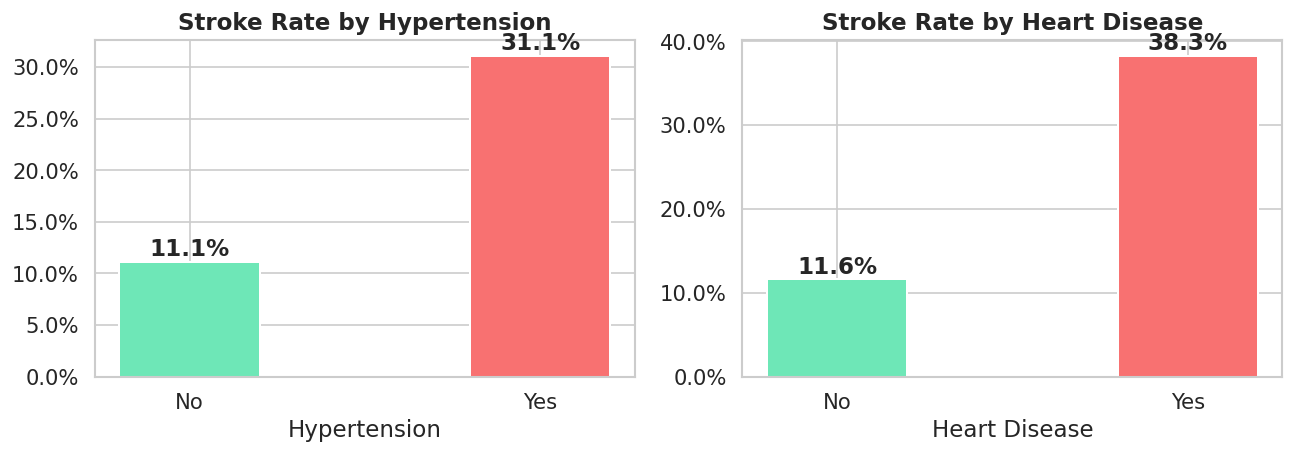

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

for ax, col, title in zip(
    axes,
    ['hypertension', 'heart_disease'],
    ['Hypertension', 'Heart Disease'],
):
    ct = df.groupby(col)['stroke'].mean().rename({0: 'No', 1: 'Yes'})
    ax.bar(['No', 'Yes'], ct.values * 100, color=['#6EE7B7', '#F87171'],
           edgecolor='white', linewidth=1.2, width=0.4)
    ax.yaxis.set_major_formatter(mtick.PercentFormatter())
    ax.set_title(f'Stroke Rate by {title}', fontweight='bold')
    ax.set_xlabel(title)
    for i, v in enumerate(ct.values * 100):
        ax.text(i, v + 0.1, f'{v:.1f}%', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

## 7. Correlation Matrix (Numeric Features)

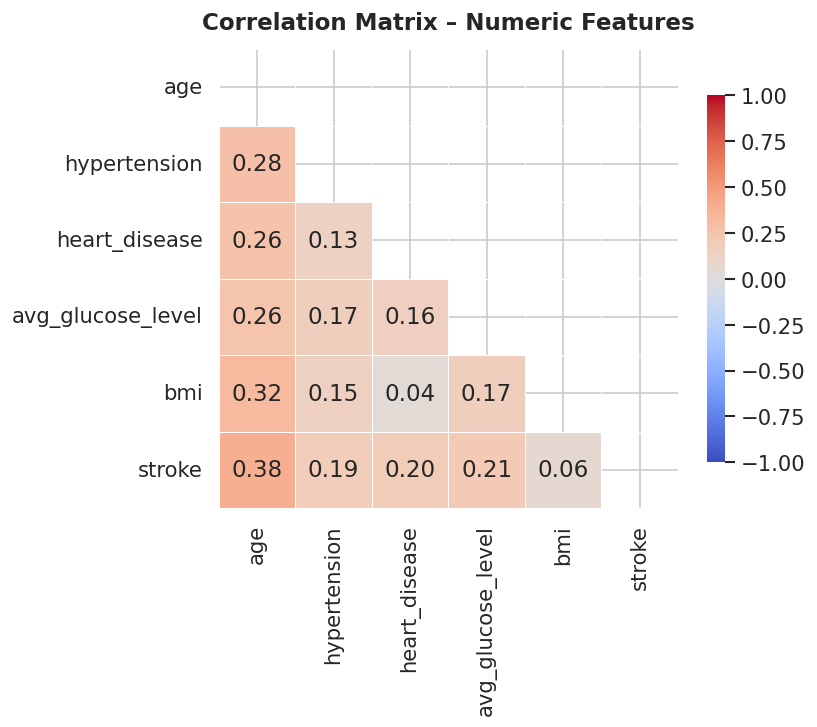

In [8]:
num_cols = ['age', 'hypertension', 'heart_disease', 'avg_glucose_level', 'bmi', 'stroke']
corr = df[num_cols].corr()

fig, ax = plt.subplots(figsize=(7, 6))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(
    corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
    vmin=-1, vmax=1, linewidths=0.5, ax=ax, square=True,
    cbar_kws={'shrink': 0.8}
)
ax.set_title('Correlation Matrix – Numeric Features', fontweight='bold', pad=12)
plt.tight_layout()
plt.show()

## 8. BMI Missing Value Analysis

Missing BMI: 201 rows (3.6%)

Stroke rate:
bmi_missing
BMI present    13.11%
BMI missing    19.90%
Name: stroke, dtype: object


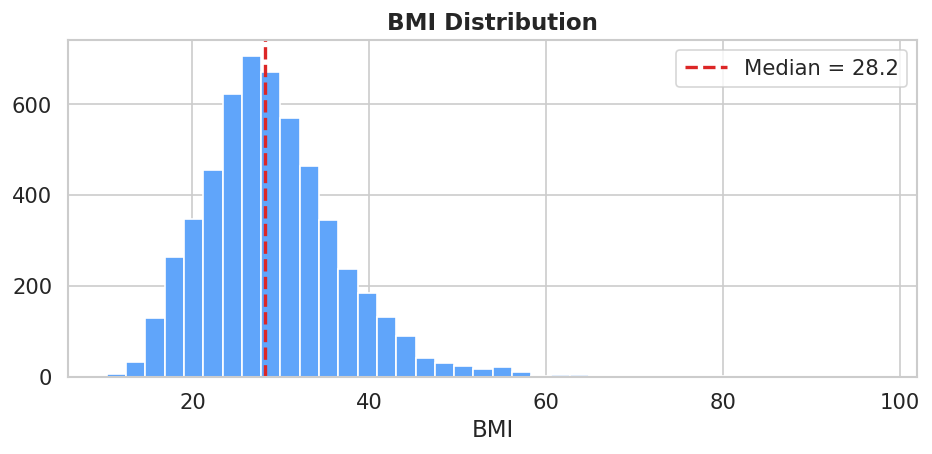

In [9]:
missing_bmi_pct = df['bmi'].isna().mean() * 100
print(f'Missing BMI: {df["bmi"].isna().sum()} rows ({missing_bmi_pct:.1f}%)')

# Are missing-BMI rows different on stroke rate?
df['bmi_missing'] = df['bmi'].isna()
print('\nStroke rate:')
print(df.groupby('bmi_missing')['stroke'].mean().rename({False: 'BMI present', True: 'BMI missing'}).map('{:.2%}'.format))

# Distribution of BMI
fig, ax = plt.subplots(figsize=(8, 4))
df['bmi'].dropna().hist(bins=40, color='#60A5FA', edgecolor='white', ax=ax)
ax.axvline(df['bmi'].median(), color='#DC2626', ls='--', lw=2, label=f'Median = {df["bmi"].median():.1f}')
ax.set_title('BMI Distribution', fontweight='bold')
ax.set_xlabel('BMI')
ax.legend()
plt.tight_layout()
plt.show()

## 9. Key Takeaways

| Insight | Implication |
|---------|-------------|
| 4.9 % positive rate | Use ROC-AUC / F1 as metrics; accuracy alone is misleading |
| Age is the strongest predictor | Stroke patients are ~20 years older on average |
| Hypertension ×2 stroke rate | Important binary risk factor |
| Heart disease ×3 stroke rate | Strong binary risk factor |
| avg_glucose_level elevated | Consistent with diabetes–stroke link |
| BMI 201 NaN (3.9%) | Impute with median (robust to right skew) |
| 'Other' gender (1 sample) | Recode to mode to avoid sparse dummy |

---
*Next step → `python src/main.py` to train AutoGluon and evaluate.*